# Exploring Change Over Time

> 30 minutes

<p style="text-align: left;">
[![JupyterLite](https://gist.githubusercontent.com/xiaohk/9b9f7c8fa162b2c3bc3251a5c9a799b2/raw/a7fca1d0a2d62c2b49f60c0217dffbd0fe404471/lite-badge-launch-small.svg)](../../assets/jupyterlite/index.html)
</p>

In this session, we will explore how embeddings can be used to analyse change over time in a given area. The premise is (relatively) simple: if an embedding captures the content of an image in a series of numbers, we can use the changes in these numbers between the embeddings of an area across two periods of time to evaluate how much the area has changed.

We structure the analysis in four stages:

1. Compute distances over time
2. Explore change through these distances
3. Mapping change
4. Identifying types of change

## Setup

In [1]:
import geopandas
import pandas

For this session, we will be using the 2020 and 2024 versions of our embeddings for London LSOA's data product. If you have not downloaded it yet, have a look at the [data section in Materials](../../Materials.qmd#data).

We'll go ahead and read the file with geometries and the embeddings (and set the area code as indices):

In [2]:
emb20 = geopandas.read_file('uk_lsoa_london_embeds_2020.geojson').set_index('data_zone_code')
emb24 = geopandas.read_file('uk_lsoa_london_embeds_2024.geojson').set_index('data_zone_code')

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/envs/gds/share/proj failed


## Compute distances across periods

To compute distances, we rely on the same ideas we discussed in the [previous session](01-Semantic_similarity). We will use cosine distances but to what we apply them will change. Instead of computing distances between the embeddings of different areas, we will calculate them for the same area across two different periods. For this, `paired_cosine_distances` in Scikit-learn is a good fit:

In [3]:
from sklearn.metrics.pairwise import paired_cosine_distances

This will calculate the distance, row-wise, for the embeddings of each area between 2020 and 2024:

In [4]:
distances = paired_cosine_distances(
    emb20.loc[:, 'A00_mean':'A63_mean'].values,
    emb24.loc[:, 'A00_mean':'A63_mean'].values
)
distances = pandas.Series(distances, index=emb20.index)

## Explore change

Once we have the distance calculated, we can have a look:

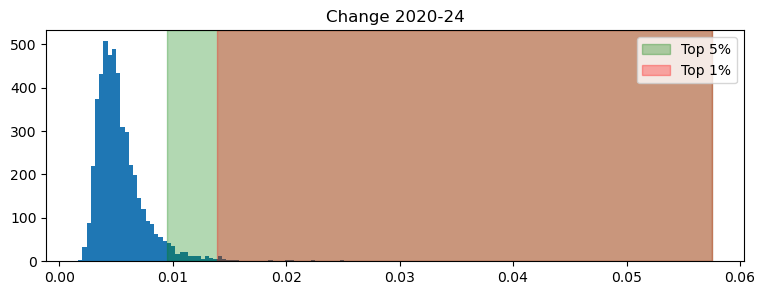

In [5]:
#| code-fold: true

import matplotlib.pyplot as plt

p95 = distances.quantile(0.95)
p99 = distances.quantile(0.99)

fig, ax = plt.subplots(figsize=(9, 3))
n, bins, patches = ax.hist(distances, bins=150)

ax.axvspan(p95, distances.max(), color='green', alpha=0.3, label='Top 5%')
ax.axvspan(p99, distances.max(), color='red', alpha=0.3, label='Top 1%')

ax.set_title("Change 2020-24")

ax.legend()
plt.show()


Note how heavily skewed the distribution is. This has a direct interpretation in meaningful terms: while most areas have not experienced much change, a few (particularly the top 1%), has seen significant differences recorded in the embedding numbers.

## Identify changing areas

Knowing some areas have changed is all good and well but, as geographers, the next question this raises is obvious: _where_ are such areas? In other words, what is the geography of change? Exploring this with our setup is fairly straight foward. For example, here're the areas in the top 5% of the plot above:

Areas between top 5% and 1%:

In [6]:
#| code-fold: true

top5 = distances[distances > p95].index
(
    emb20
    .loc[top5, ['geometry']]
    .explore()
)

:::{.callout-tip title="Home assignment"}

Make a similar map for the top 1%. Where are the areas that _really_ have changed?
:::

## Becoming more like...

We now take everything we've learned in both sessions and apply to the following question: can we use embeddings to identify areas that have become _more like_ other areas? For example, which area became more like Hyde Park in the period between 2020 and 2024?

To answer this question, we need to unpack it into the building blocks of an answer. To find out which LSOA changed more towards the character of Hyde Park, we can follow these steps:

1. Calculate the distance between every area and Hyde Park in 2020
2. Calculate the distance between every area and Hyde Park in 2024
3. Obtain the difference between both distances, for every LSOA
4. Pick the largest difference

Let's get to work. To calculate these distances, we rely on a slightly different version of what we used above. `cosine_distances` will give us the distance between _all_ the observations in two sets of data (unlike between every row, as we had above).

In [7]:
from sklearn.metrics.pairwise import cosine_distances

We can then identify Hyde Park, and obtain the distances for both years:

In [8]:
hyde_park = 'E01035718'

dist2hyde_park20 = cosine_distances(              # <1>
    emb20.loc[:, 'A00_mean':'A63_mean'],          # <2>
    emb20.loc[[hyde_park], 'A00_mean':'A63_mean'] # <3>
).flatten()                                       # <4>
dist2hyde_park24 = cosine_distances(
    emb24.loc[:, 'A00_mean':'A63_mean'],
    emb24.loc[[hyde_park], 'A00_mean':'A63_mean']
).flatten()

1. Use `cosine_distances` instead of `paired_cosine_distances`
2. Select the part of each table that contains only the embedding dimensions, excluding area codes, geometries, etc.
3. Select the embedding for Hyde Park
4. The result is a 2D array and we need it in 1D form, wich `flatten` does for us

With these at hand, we can calculate the change in distance (i.e., how much dis/similar each area has become to Hyde Park):

In [9]:
distance_diff = dist2hyde_park24 - dist2hyde_park20             # <1>
distance_diff = pandas.Series(distance_diff, index=emb20.index) # <2>

1. Substract distance in 2020 from the distance in 2024
2. Convert array into a `pandas.Series` for convenience

We can pick the LSOA that has become the most like Hyde Park through a bit of manipulation:

In [10]:
winner = distance_diff[distance_diff == distance_diff.min()].index[0]

Now, note that becoming the most like Hyde Park does not mean changing much. Actually, our winner has not moved much, by the standards in our first graph above. But it _is_ the area that move the most _in the direction_ of Hyde Park (in embedding space, that is).

In [11]:
distances[winner]

np.float64(0.007886517002039047)

_Where_ is this place?

In [12]:
#| code-fold: true
emb20.loc[[winner], ['geometry']].explore()

And, can we make a wild guess as to _why_ Battersea station takes the trophy? [^1]

[^1]: The figures below are screenshots from [Google Earth](https://earth.google.com/web/search/Battersea+Power+Station,+Circus+Road+West,+London/@51.48225821,-0.14362618,13.41773656a,854.69539249d,35y,0h,0t,0r/data=Cj4iJgokCZLpQLu9uElAERM7-U3ctklAGcQWgB32I9O_IeBuZyxozNW_KhAIARIKMjAyMC0wMS0xOBgBQgIIAUICCABKDQj___________8BEAA), using its time travel tool (which is pretty cool).

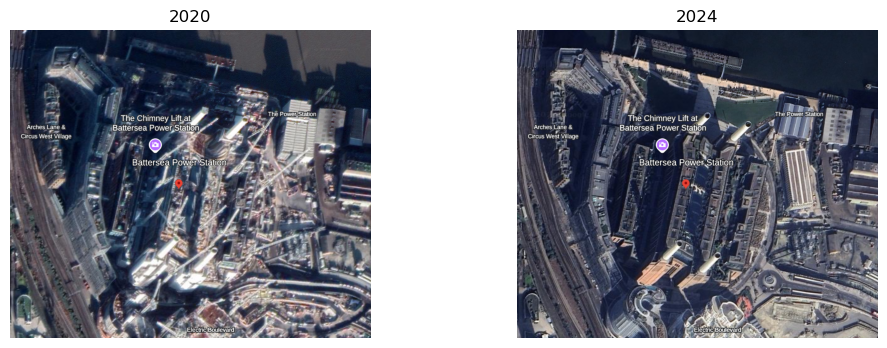

In [13]:
#| code-fold: true

import matplotlib.image as mpimg

img1 = mpimg.imread('hp_like20.png')
img2 = mpimg.imread('hp_like24.png')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title('2020')
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title('2024')
plt.show()

:::{.callout-tip title="Home assignment"}

Who's got more like Canary Wharf?
:::